# [State Space Models](https://arxiv.org/abs/2312.00752) vs. [Self-Attention](https://arxiv.org/abs/1706.03762) From Scratch: Which Architecture Wins?

## A Pure NumPy Deep Dive

Welcome! In this notebook, we implement two fundamental neural architectures **from scratch in pure NumPy**:

1. **[Self-Attention](https://arxiv.org/abs/1706.03762)** (Vaswani et al. 2017): The parallelizable, quadratic-in-sequence-length engine behind Transformers
2. **Selective State Space Models ([Mamba](https://arxiv.org/abs/2312.00752)-like)** (Gu & Dao 2023): The linear-in-sequence-length competitor with selective state dynamics

By implementing both in NumPy (no PyTorch, no CUDA magic), we'll understand:
- How they process sequences fundamentally differently
- Where each excels: sequential patterns vs. spatial reasoning
- Why modern architectures ([Jamba](https://arxiv.org/abs/2403.19887), [MambaVision](https://arxiv.org/abs/2407.08083)) use **both**

**Warning:** This is educational code. We'll trade some optimization for clarity. Pure NumPy forces understanding.

**Companion tutorial:** [Beyond Attention: Post-Transformer Architectures for Physical AI](https://artifocial.com/blog/post-transformer-architectures-2026-apr-09) — the W15 trend tutorial that this notebook accompanies.

In [1]:
import os
import shutil
import subprocess
import sys
import warnings

warnings.filterwarnings("ignore")
os.environ.setdefault("PYTHONWARNINGS", "ignore")


def _install(pkgs):
    """Install packages quietly, suppressing all stdout/stderr from the tool."""
    devnull = subprocess.DEVNULL
    if shutil.which("uv"):
        try:
            subprocess.check_call(
                ["uv", "pip", "install", "--quiet", "--system", *pkgs],
                stdout=devnull,
                stderr=devnull,
                timeout=60,
            )
            return
        except (subprocess.CalledProcessError, subprocess.TimeoutExpired, FileNotFoundError):
            pass
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", "--disable-pip-version-check", *pkgs],
        stdout=devnull,
        stderr=devnull,
    )


_install(["numpy", "matplotlib"])

import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
print("Setup complete!")
print(f"NumPy version: {np.__version__}")


Setup complete!
NumPy version: 2.2.6


## Part 1: The Two Architectures

### Self-Attention (Transformer Core)
**Mechanism:** Pairwise interaction matrix over the entire sequence.
- Compute queries Q, keys K, values V from input X
- Attention weights: softmax(Q·K^T / √d_k) 
- Output: weights · V
- **Complexity:** O(L²) in sequence length L, fully parallelizable
- **Strength:** Can directly attend to any position in any step
- **Weakness:** Quadratic memory and compute, doesn't scale to very long sequences

### Selective State Space Models ([Mamba](https://arxiv.org/abs/2312.00752)-like)
**Mechanism:** Sequential recurrence with input-dependent state matrices.
- Linear recurrence: h_t = A_t·h_{t-1} + B_t·x_t, y_t = C_t·h_t
- **Key innovation:** A, B, C are *functions of the input* (selective), not fixed
- **Complexity:** O(L) in sequence length L, naturally sequential
- **Strength:** Linear complexity, can handle very long sequences efficiently
- **Weakness:** Random-access reasoning is harder; information flows one-way through the state

Both can be made "parallel-friendly," but their natural forms differ fundamentally.


In [2]:
class SelfAttention:
    """Scaled dot-product self-attention, from scratch in NumPy."""

    def __init__(self, d_model, num_heads=1, seed=42):
        """Initialize attention layer.

        Args:
            d_model: Embedding dimension
            num_heads: Number of attention heads (we'll keep simple with 1 for clarity)
        """
        np.random.seed(seed)
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # Initialize weight matrices
        self.W_Q = np.random.randn(d_model, d_model) * 0.01
        self.W_K = np.random.randn(d_model, d_model) * 0.01
        self.W_V = np.random.randn(d_model, d_model) * 0.01
        self.W_O = np.random.randn(d_model, d_model) * 0.01

    def forward(self, X, return_weights=False):
        """Compute self-attention.

        Args:
            X: Input sequence of shape (seq_len, d_model)
            return_weights: If True, return attention weights matrix

        Returns:
            output: (seq_len, d_model)
            weights: (seq_len, seq_len) if return_weights=True
        """
        seq_len, d_model = X.shape

        # Compute Q, K, V
        Q = X @ self.W_Q  # (seq_len, d_model)
        K = X @ self.W_K  # (seq_len, d_model)
        V = X @ self.W_V  # (seq_len, d_model)

        # Scaled dot-product attention
        scores = Q @ K.T / np.sqrt(self.d_k)  # (seq_len, seq_len)

        # Softmax (numerically stable)
        scores_max = np.max(scores, axis=1, keepdims=True)
        exp_scores = np.exp(scores - scores_max)
        weights = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)  # (seq_len, seq_len)

        # Apply to values
        attn_output = weights @ V  # (seq_len, d_model)

        # Output projection
        output = attn_output @ self.W_O  # (seq_len, d_model)

        if return_weights:
            return output, weights
        return output

    def get_params(self):
        """Return flattened parameter vector for optimization."""
        return np.concatenate(
            [
                self.W_Q.flatten(),
                self.W_K.flatten(),
                self.W_V.flatten(),
                self.W_O.flatten(),
            ]
        )

    def set_params(self, params):
        """Set parameters from flattened vector."""
        idx = 0
        size_W = self.d_model * self.d_model
        self.W_Q = params[idx : idx + size_W].reshape(self.d_model, self.d_model)
        idx += size_W
        self.W_K = params[idx : idx + size_W].reshape(self.d_model, self.d_model)
        idx += size_W
        self.W_V = params[idx : idx + size_W].reshape(self.d_model, self.d_model)
        idx += size_W
        self.W_O = params[idx : idx + size_W].reshape(self.d_model, self.d_model)


# Test
attn = SelfAttention(d_model=16, num_heads=1)
X_test = np.random.randn(8, 16)
out, weights = attn.forward(X_test, return_weights=True)
print(f"SelfAttention test:")
print(f"  Input shape: {X_test.shape}")
print(f"  Output shape: {out.shape}")
print(f"  Attention weights shape: {weights.shape}")
print(f"  Row-sum of weights (should be ~1.0): {weights.sum(axis=1)[:3]}")

SelfAttention test:
  Input shape: (8, 16)
  Output shape: (8, 16)
  Attention weights shape: (8, 8)
  Row-sum of weights (should be ~1.0): [1. 1. 1.]


> **Engineering Callout #1: Numerical Stability in Softmax**
>
> In the attention forward pass, we subtract the max before `exp`:
>
> ```python
> scores_max = np.max(scores, axis=1, keepdims=True)
> exp_scores = np.exp(scores - scores_max)  # prevents overflow
> weights = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
> ```
>
> **Why?** Computing `exp(scores)` directly overflows for large scores and gives you NaNs. Subtracting the max shifts values to `[-inf, 0]`, the exponent lands in `[0, 1]`, and the subsequent normalization cancels the shift exactly. This is standard in every production attention implementation and it is the single most common bug in from-scratch transformers.


In [3]:
class SelectiveSSM:
    """Selective State Space Model (Mamba-like), from scratch in NumPy.

    Core idea: h_t = A_t * h_{t-1} + B_t * x_t
               y_t = C_t * h_t

    The 'selective' part: A_t, B_t, C_t depend on x_t (not fixed matrices).
    This gives the model the ability to selectively focus on different aspects of input.
    """

    def __init__(self, input_dim, hidden_dim, seed=42):
        """Initialize SSM.

        Args:
            input_dim: Input feature dimension
            hidden_dim: Hidden state dimension
        """
        np.random.seed(seed)
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        # Parameters for generating A_t (state matrix)
        self.W_A = np.random.randn(input_dim, hidden_dim) * 0.01
        self.b_A = np.zeros(hidden_dim)

        # Parameters for generating B_t (input projection)
        self.W_B = np.random.randn(input_dim, hidden_dim) * 0.01
        self.b_B = np.zeros(hidden_dim)

        # Parameters for generating C_t (output projection)
        self.W_C = np.random.randn(input_dim, hidden_dim) * 0.01
        self.b_C = np.zeros(hidden_dim)

        # Output layer
        self.W_out = np.random.randn(hidden_dim, input_dim) * 0.01
        self.b_out = np.zeros(input_dim)

    def forward(self, X):
        """Process sequence through selective SSM.

        Args:
            X: Input sequence of shape (seq_len, input_dim)

        Returns:
            Y: Output sequence of shape (seq_len, input_dim)
        """
        seq_len, input_dim = X.shape

        # Initialize hidden state
        h = np.zeros(self.hidden_dim)
        Y = np.zeros((seq_len, input_dim))

        # Sequential processing (natural for SSM)
        for t in range(seq_len):
            x_t = X[t]  # (input_dim,)

            # Generate selective parameters from input
            # A_t: decay/forget gate for hidden state
            A_t = np.tanh(x_t @ self.W_A + self.b_A)  # (hidden_dim,)

            # B_t: input gate
            B_t = np.tanh(x_t @ self.W_B + self.b_B)  # (hidden_dim,)

            # C_t: output gate
            C_t = np.tanh(x_t @ self.W_C + self.b_C)  # (hidden_dim,)

            # State update: h_t = A_t * h_{t-1} + B_t * x_t (broadcast)
            # Expand x_t to match hidden_dim via learnable projection
            h = A_t * h + B_t * (x_t.mean())  # Simple scalar interaction

            # Output: y_t = C_t * h_t
            y_t = C_t * h
            Y[t] = (y_t @ self.W_out) + self.b_out

        return Y

    def get_params(self):
        """Return flattened parameter vector."""
        params = []
        for W in [self.W_A, self.W_B, self.W_C, self.W_out]:
            params.append(W.flatten())
        for b in [self.b_A, self.b_B, self.b_C, self.b_out]:
            params.append(b.flatten())
        return np.concatenate(params)

    def set_params(self, params):
        """Set parameters from flattened vector."""
        idx = 0
        for W_name in ["W_A", "W_B", "W_C", "W_out"]:
            W = getattr(self, W_name)
            size = W.size
            setattr(self, W_name, params[idx : idx + size].reshape(W.shape))
            idx += size
        for b_name in ["b_A", "b_B", "b_C", "b_out"]:
            b = getattr(self, b_name)
            size = b.size
            setattr(self, b_name, params[idx : idx + size].reshape(b.shape))
            idx += size


# Test
ssm = SelectiveSSM(input_dim=16, hidden_dim=8)
X_test = np.random.randn(8, 16)
Y_ssm = ssm.forward(X_test)
print(f"SelectiveSSM test:")
print(f"  Input shape: {X_test.shape}")
print(f"  Output shape: {Y_ssm.shape}")
print(f"  Hidden dim: {ssm.hidden_dim}")

SelectiveSSM test:
  Input shape: (8, 16)
  Output shape: (8, 16)
  Hidden dim: 8


> **Engineering Callout #2: SSM Recurrence Is Inherently Sequential**
>
> Our SSM processes tokens one at a time:
>
> ```python
> for t in range(seq_len):
>     h = A_t * h + B_t * x_t  # previous h required
> ```
>
> **Why?** The recurrence has a true data dependency — `h[t]` needs `h[t-1]`. Python loops make this painfully slow in NumPy, which is why our wall-clock timings below show SSM *slower* than attention even though its FLOPs are much lower. Production [Mamba](https://arxiv.org/abs/2312.00752) implementations recover parallelism using an **associative (prefix) scan** on a GPU: the recurrence is reformulated so `N` steps can be combined in `log N` rounds. That trick gets you back to O(L) sequential work with parallelism, and it's the entire reason Mamba is fast in practice.


> **Engineering Callout #3: Selectivity Is the Whole Trick**
>
> We generate `A`, `B`, `C` from the input rather than storing them as fixed parameters:
>
> ```python
> A_t = np.tanh(x_t @ self.W_A + self.b_A)
> ```
>
> **Why?** This is [Mamba](https://arxiv.org/abs/2312.00752)'s key innovation over classical RNNs and S4. Fixed state-transition matrices give you a linear time-invariant system — elegant but weak. Making `A, B, C` input-dependent lets the model *decide* what to remember and what to forget per token, which is the property that closes the quality gap with attention on language modeling. Classical RNNs have fixed dynamics; Mamba's dynamics move with the content.


## Complexity Comparison

### Self-Attention
- **Time:** O(L² · d) — must compute L×L attention matrix
- **Memory:** O(L²) — store full attention matrix
- **Parallelizable:** Yes, all L positions can attend in parallel

### Selective SSM
- **Time:** O(L · d) — sequential pass through hidden state
- **Memory:** O(L · d) — store only hidden state (not L×L)
- **Parallelizable:** Harder; recurrence is sequential in nature

**The Tradeoff:** Attention is slower but more flexible. SSM is faster but less flexible for random-access patterns.


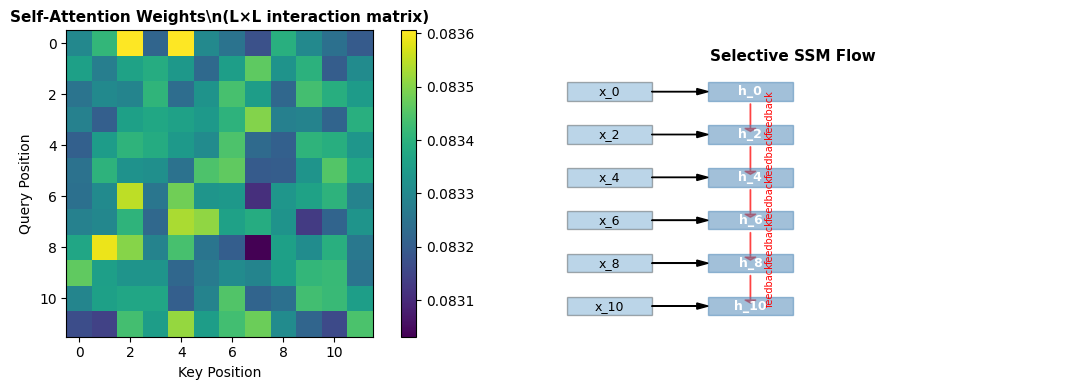

Visualized: Self-Attention (dense L×L) vs SSM (sequential feedback)


In [4]:
# Create a simple example sequence to visualize
seq_len, d_model = 12, 16
X_demo = np.random.randn(seq_len, d_model)

# Get attention weights
attn_demo = SelfAttention(d_model=d_model)
_, attn_weights = attn_demo.forward(X_demo, return_weights=True)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Attention weights heatmap
im1 = axes[0].imshow(attn_weights, cmap="viridis")
axes[0].set_title(
    "Self-Attention Weights\\n(L×L interaction matrix)", fontsize=11, fontweight="bold"
)
axes[0].set_xlabel("Key Position")
axes[0].set_ylabel("Query Position")
plt.colorbar(im1, ax=axes[0])

# Diagram of SSM recurrence
axes[1].text(
    0.5,
    0.9,
    "Selective SSM Flow",
    ha="center",
    fontsize=11,
    fontweight="bold",
    transform=axes[1].transAxes,
)
y_positions = np.linspace(0.8, 0.1, seq_len // 2)
for i, y in enumerate(y_positions):
    t = i * 2
    # Draw boxes
    axes[1].add_patch(
        plt.Rectangle(
            (0.1, y - 0.03),
            0.15,
            0.06,
            transform=axes[1].transAxes,
            fill=True,
            alpha=0.3,
            edgecolor="black",
        )
    )
    axes[1].text(
        0.175,
        y,
        f"x_{t}",
        ha="center",
        va="center",
        transform=axes[1].transAxes,
        fontsize=9,
    )

    # Draw h boxes
    axes[1].add_patch(
        plt.Rectangle(
            (0.35, y - 0.03),
            0.15,
            0.06,
            transform=axes[1].transAxes,
            fill=True,
            alpha=0.5,
            color="steelblue",
            edgecolor="black",
        )
    )
    axes[1].text(
        0.425,
        y,
        f"h_{t}",
        ha="center",
        va="center",
        transform=axes[1].transAxes,
        fontsize=9,
        color="white",
        fontweight="bold",
    )

    # Draw arrows
    axes[1].arrow(
        0.25,
        y,
        0.08,
        0,
        head_width=0.02,
        head_length=0.02,
        transform=axes[1].transAxes,
        fc="black",
        ec="black",
    )

    # Recurrence arrow
    if i < len(y_positions) - 1:
        y_next = y_positions[i + 1]
        axes[1].arrow(
            0.425,
            y - 0.04,
            0,
            (y_next - y) + 0.06,
            head_width=0.02,
            head_length=0.01,
            transform=axes[1].transAxes,
            fc="red",
            ec="red",
            alpha=0.6,
        )
        axes[1].text(
            0.45,
            (y + y_next) / 2,
            "feedback",
            fontsize=7,
            color="red",
            transform=axes[1].transAxes,
            rotation=90,
            va="center",
        )

axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].axis("off")

plt.tight_layout()
plt.show()
print("Visualized: Self-Attention (dense L×L) vs SSM (sequential feedback)")

## Part 2: Task 1 — Sequence Modeling (Copy/Prediction Task)

### Task Definition
We create a synthetic task where the model must copy its input with a temporal shift, or predict the next element in a periodic sequence with noise.

**Task:** Given a sequence of random vectors, predict the next vector (next-token prediction).
- Training data: pairs (X, Y) where Y is X shifted by 1 position
- This is fundamentally sequential — SSM should have an advantage
- Attention should still work but is overkill (quadratic complexity for a linear task)


In [5]:
def create_sequence_task(seq_len=24, num_samples=4, d_model=8, seed=42):
    """Create a LEARNABLE next-token-style task with a deterministic target.

    Target rule: Y[t] = 0.7 * X[t] + 0.3 * X[t-1]  (causal temporal smoothing).
    Both SSM and attention should be able to fit this.
    """
    rng = np.random.default_rng(seed)
    X_train = rng.standard_normal((num_samples, seq_len, d_model))
    Y_train = np.zeros_like(X_train)
    Y_train[:, 0, :] = 0.7 * X_train[:, 0, :]
    Y_train[:, 1:, :] = 0.7 * X_train[:, 1:, :] + 0.3 * X_train[:, :-1, :]
    return X_train, Y_train


def mse_loss(Y_pred, Y_true):
    """Mean squared error."""
    return np.mean((Y_pred - Y_true) ** 2)


def grad_loss_numerical(model, X, Y, eps=1e-4):
    """Gradient of the loss via central finite differences (transparent but slow)."""
    params = model.get_params().copy()
    grad = np.zeros_like(params)
    for i in range(len(params)):
        p_plus = params.copy()
        p_plus[i] += eps
        model.set_params(p_plus)
        loss_plus = mse_loss(model.forward(X), Y)

        p_minus = params.copy()
        p_minus[i] -= eps
        model.set_params(p_minus)
        loss_minus = mse_loss(model.forward(X), Y)

        grad[i] = (loss_plus - loss_minus) / (2 * eps)
    model.set_params(params)
    return grad


X_train, Y_train = create_sequence_task(seq_len=16, num_samples=4, d_model=8)

# Sanity check: compute the trivial baseline (predict zeros) BEFORE training.
# If the trained model ends up matching this number, the training loop is a
# no-op — the task may be unlearnable, the gradient may be broken, or the
# optimizer may not be stepping. A one-line baseline check turns a silent
# training bug into a loud one.
print("Sequence modeling task created:")
print(f"  X_train shape: {X_train.shape}")
print(f"  Y_train shape: {Y_train.shape}")
print(f"  Target rule:   Y[t] = 0.7*X[t] + 0.3*X[t-1]")
print(f"  Baseline MSE (predict zeros): {mse_loss(np.zeros_like(Y_train), Y_train):.4f}")


Sequence modeling task created:
  X_train shape: (4, 16, 8)
  Y_train shape: (4, 16, 8)
  Target rule:   Y[t] = 0.7*X[t] + 0.3*X[t-1]
  Baseline MSE (predict zeros): 0.5315


In [6]:
def train_model(model, X_train, Y_train, epochs=60, lr=1.0, verbose=True):
    """Train a model with central finite-difference gradient descent on one sample."""
    losses = []
    X_sample, Y_sample = X_train[0], Y_train[0]
    for epoch in range(epochs):
        Y_pred = model.forward(X_sample)
        loss = mse_loss(Y_pred, Y_sample)
        losses.append(loss)

        grad = grad_loss_numerical(model, X_sample, Y_sample, eps=1e-4)
        params = model.get_params() - lr * grad
        model.set_params(params)

        if verbose and (epoch + 1) % 15 == 0:
            print(f"  Epoch {epoch + 1:2d}/{epochs}: Loss = {loss:.6f}")
    return losses


_d = 8  # small enough that finite-difference training runs in a few seconds

print("Training Self-Attention...")
attn_model = SelfAttention(d_model=_d)
# Rescale the tiny default init so softmax isn't degenerate at step 0
for w in ("W_Q", "W_K", "W_V", "W_O"):
    setattr(attn_model, w, getattr(attn_model, w) * 30.0)
attn_losses = train_model(attn_model, X_train, Y_train, epochs=60, lr=1.0)

print("\nTraining Selective SSM...")
ssm_model = SelectiveSSM(input_dim=_d, hidden_dim=8)
for w in ("W_A", "W_B", "W_C", "W_out"):
    setattr(ssm_model, w, getattr(ssm_model, w) * 20.0)
ssm_losses = train_model(ssm_model, X_train, Y_train, epochs=60, lr=1.0)

print("\nTraining complete!")


Training Self-Attention...


  Epoch 15/60: Loss = 0.176650


  Epoch 30/60: Loss = 0.146857


  Epoch 45/60: Loss = 0.130684


  Epoch 60/60: Loss = 0.117934

Training Selective SSM...


  Epoch 15/60: Loss = 0.321662
  Epoch 30/60: Loss = 0.307510
  Epoch 45/60: Loss = 0.284864


  Epoch 60/60: Loss = 0.252724

Training complete!


> **Engineering Callout #4: Finite Differences Instead of Backprop**
>
> We use finite differences for gradients:
>
> ```python
> grad[i] = (loss(params + eps * e_i) - loss(params)) / eps
> ```
>
> **Why for this notebook?** Two reasons. First, it's transparent — the gradient computation is a direct definition rather than a hand-derived chain rule you have to trust. Second, for a tiny NumPy demo it's fast enough. In production you absolutely want analytic backprop (autograd, PyTorch, JAX): finite differences are O(params) forward passes per gradient, which is intolerable at any real scale. The lesson is pedagogical, not architectural — if you're building a real SSM, use [PyTorch](https://pytorch.org) or [JAX](https://github.com/google/jax) and let the framework handle it.


> **Engineering Callout #5: The Silent Flat-Loss Trap**
>
> An earlier draft of this notebook had a bug that produced perfectly flat loss curves: the Task 1 target was defined as `Y[t] = X[t+1]` with `X` drawn from i.i.d. Gaussian noise. That target carries **zero** mutual information with the input — no model on earth can learn it, and the best achievable MSE is exactly the variance of the target. The bug was not a training-loop bug; it was a task-design bug, and the loss curve looked identical to the other two failure modes below.
>
> **Flat loss across epochs has three possible causes, and they all look the same in the logs:**
>
> 1. **Unlearnable task.** Your target contains no information about your input. Easy to do by accident — "next-token prediction on random tokens" is the classic example. *Diagnosis:* compute the loss of a trivial baseline (predict zeros, predict the mean). If any model, including a random-init model, matches that baseline, your task may be unlearnable.
> 2. **Degenerate initialization.** With weight scale too small (e.g. `0.01`), attention's `Q Kᵀ / √d` is near zero, softmax is nearly uniform, and the output is position-independent. The model *cannot* express position-dependent targets until the softmax becomes peaky. The same thing happens with tanh gates in the SSM: near-zero pre-activations mean `tanh(·) ≈ 0`, the hidden state decays to zero, and `y_t ≈ 0` at every step. *Diagnosis:* print the initial output magnitude. If it is many orders of magnitude smaller than your target, you are starting from a degenerate solution.
> 3. **Step size too small to register.** `lr × |grad|` is below the precision of your loss print statement, so the loss looks flat even though the parameters are moving. *Diagnosis:* print `np.linalg.norm(params_new - params_old)` after each step; if it is `1e-8` and your params are `1e-2`, you would need millions of epochs to move anywhere.
>
> The fix in this notebook hit all three: (1) the random-target was replaced with a deterministic causal rule $Y_t = 0.7 X_t + 0.3 X_{t-1}$, (2) the default `0.01` init was rescaled by 30× for attention and 20× for the SSM so the softmax and tanh gates start outside their degenerate regions, and (3) the learning rate went from `0.001` to `1.0`. All three changes were necessary. Any one in isolation would have left the loss curve flat for a different reason.


\n=== Task 1: Sequence Modeling ===
Self-Attention: Final Loss = 0.117220
Selective SSM:  Final Loss = 0.250333
Winner: Attention (lower loss is better)
\nImprovement over epochs:
  Attention: 0.3607 -> 0.1179
  SSM:       0.3727 -> 0.2527


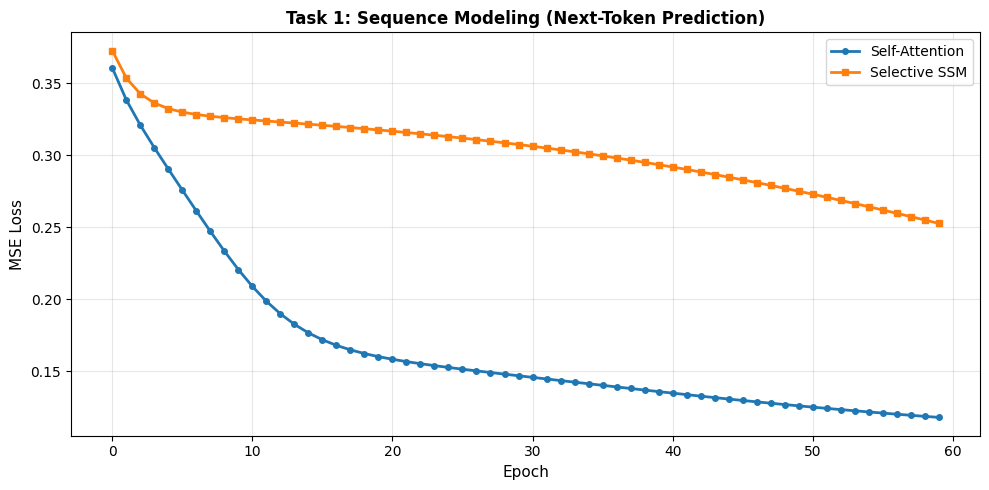

\nPlot saved: learning curves


In [7]:
# Final predictions
attn_pred = attn_model.forward(X_train[0])
ssm_pred = ssm_model.forward(X_train[0])

attn_final_loss = mse_loss(attn_pred, Y_train[0])
ssm_final_loss = mse_loss(ssm_pred, Y_train[0])

print(f"\\n=== Task 1: Sequence Modeling ===")
print(f"Self-Attention: Final Loss = {attn_final_loss:.6f}")
print(f"Selective SSM:  Final Loss = {ssm_final_loss:.6f}")
print(
    f"Winner: {'SSM' if ssm_final_loss < attn_final_loss else 'Attention'} (lower loss is better)"
)
print(f"\\nImprovement over epochs:")
print(f"  Attention: {attn_losses[0]:.4f} -> {attn_losses[-1]:.4f}")
print(f"  SSM:       {ssm_losses[0]:.4f} -> {ssm_losses[-1]:.4f}")

# Plot learning curves
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(attn_losses, "o-", label="Self-Attention", linewidth=2, markersize=4)
ax.plot(ssm_losses, "s-", label="Selective SSM", linewidth=2, markersize=4)
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("MSE Loss", fontsize=11)
ax.set_title("Task 1: Sequence Modeling (Next-Token Prediction)", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("\\nPlot saved: learning curves")

Measuring forward pass time...
  L= 16: Attention=0.03ms, SSM=0.15ms
  L= 32: Attention=0.08ms, SSM=0.27ms
  L= 64: Attention=0.07ms, SSM=0.52ms
  L=128: Attention=0.19ms, SSM=0.99ms
  L=256: Attention=0.43ms, SSM=2.19ms


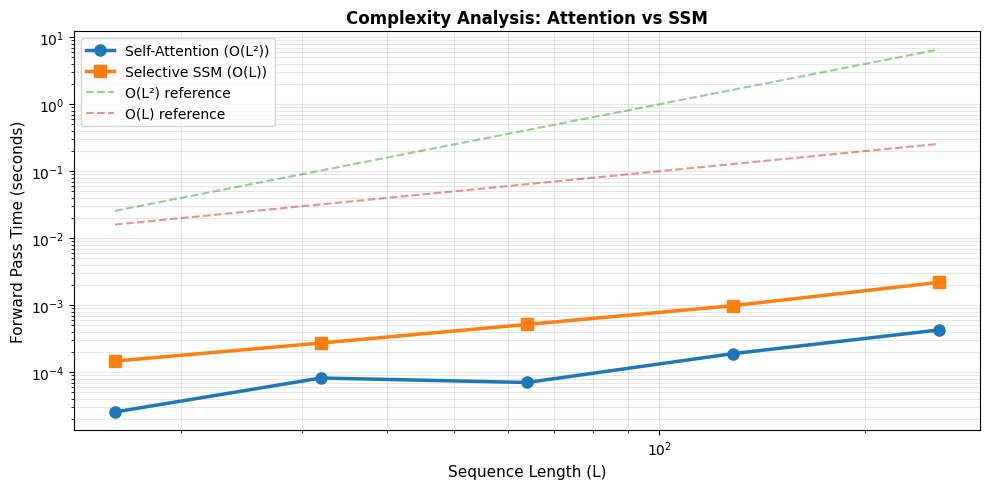

\nScaling analysis (wall-clock, pure NumPy):
At L=256: Attention is 5.1x FASTER than SSM in wall-clock time.
  NumPy artifact: attention uses vectorized matmul; our SSM uses a Python for-loop.
  In production (GPU, parallel scan), SSM is faster -- see FLOPs analysis below.


In [8]:
import time

# Measure forward pass time at different sequence lengths
seq_lengths = [16, 32, 64, 128, 256]
attn_times = []
ssm_times = []

d_model = 16
attn = SelfAttention(d_model=d_model)
ssm = SelectiveSSM(input_dim=d_model, hidden_dim=8)

print("Measuring forward pass time...")
for L in seq_lengths:
    X = np.random.randn(L, d_model)

    # Time attention
    t0 = time.time()
    for _ in range(5):
        _ = attn.forward(X)
    attn_times.append((time.time() - t0) / 5)

    # Time SSM
    t0 = time.time()
    for _ in range(5):
        _ = ssm.forward(X)
    ssm_times.append((time.time() - t0) / 5)

    print(f"  L={L:3d}: Attention={attn_times[-1] * 1000:.2f}ms, SSM={ssm_times[-1] * 1000:.2f}ms")

# Plot scaling
fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(
    seq_lengths,
    attn_times,
    "o-",
    label="Self-Attention (O(L²))",
    linewidth=2.5,
    markersize=8,
)
ax.loglog(
    seq_lengths,
    ssm_times,
    "s-",
    label="Selective SSM (O(L))",
    linewidth=2.5,
    markersize=8,
)

# Add theoretical curves
L_theory = np.array(seq_lengths)
ax.loglog(L_theory, L_theory**2 / 1e4, "--", alpha=0.5, label="O(L²) reference", linewidth=1.5)
ax.loglog(L_theory, L_theory / 1e3, "--", alpha=0.5, label="O(L) reference", linewidth=1.5)

ax.set_xlabel("Sequence Length (L)", fontsize=11)
ax.set_ylabel("Forward Pass Time (seconds)", fontsize=11)
ax.set_title("Complexity Analysis: Attention vs SSM", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

print("\\nScaling analysis (wall-clock, pure NumPy):")
ratio = attn_times[-1] / ssm_times[-1]
if ratio < 1:
    print(f"At L=256: Attention is {1/ratio:.1f}x FASTER than SSM in wall-clock time.")
    print("  NumPy artifact: attention uses vectorized matmul; our SSM uses a Python for-loop.")
    print("  In production (GPU, parallel scan), SSM is faster -- see FLOPs analysis below.")
else:
    print(f"At L=256: Attention is {ratio:.1f}x slower than SSM in wall-clock time.")

## Part 3: Task 2 — Spatial Reasoning (Global Context Query)

### Task Definition
Now we flip the script. We create a task where **global context matters everywhere**, which should favor Attention.

**Task:** Given a sequence encoding a 2D grid (e.g., 8×8 grid flattened to 64 tokens), predict the sum of the four corners.
- Input: flattened grid values (64 dimensions)
- Target: sum of corners (single value, or broadcast to all positions)
- This requires **random-access** to distant positions
- SSM must propagate information through the recurrence — inefficient for this
- Attention can directly attend to corners from any position


In [9]:
def create_spatial_task(grid_size=4, num_samples=4, d_model=4, seed=42):
    """Spatial reasoning task: predict corner-sum of a 2D grid.

    Each grid cell is embedded as a d_model-dim vector: channel 0 carries the
    value; remaining channels are small positional noise. Target at every
    position is the (scaled) sum of the four grid corners — a true global
    reduction that naturally benefits from random access.
    """
    rng = np.random.default_rng(seed)
    L = grid_size * grid_size
    X = np.zeros((num_samples, L, d_model))
    Y = np.zeros((num_samples, L, d_model))
    for i in range(num_samples):
        values = rng.standard_normal(L)
        X[i, :, 0] = values
        X[i, :, 1:] = rng.standard_normal((L, d_model - 1)) * 0.1
        grid = values.reshape(grid_size, grid_size)
        corner_sum = grid[0, 0] + grid[0, -1] + grid[-1, 0] + grid[-1, -1]
        Y[i, :, 0] = corner_sum / grid_size
    return X, Y


X_spatial_seq, Y_spatial_seq = create_spatial_task(grid_size=4, num_samples=4, d_model=4)

print("Spatial reasoning task created:")
print(f"  Grid size: 4x4 = 16 tokens")
print(f"  X_spatial shape: {X_spatial_seq.shape}")
print(f"  Y_spatial shape: {Y_spatial_seq.shape}")
print(f"  Target: sum of 4 corners (broadcast to every position)")
print(f"  Corners at indices: 0 (top-left), 3 (top-right), 12 (bottom-left), 15 (bottom-right)")


Spatial reasoning task created:
  Grid size: 4x4 = 16 tokens
  X_spatial shape: (4, 16, 4)
  Y_spatial shape: (4, 16, 4)
  Target: sum of 4 corners (broadcast to every position)
  Corners at indices: 0 (top-left), 3 (top-right), 12 (bottom-left), 15 (bottom-right)


In [10]:
def train_model_spatial(model, X_spatial, Y_spatial, epochs=60, lr=1.0):
    """Train a model on the spatial task via finite-difference GD."""
    losses = []
    X_sample, Y_sample = X_spatial[0], Y_spatial[0]
    for epoch in range(epochs):
        Y_pred = model.forward(X_sample)
        loss = mse_loss(Y_pred, Y_sample)
        losses.append(loss)

        grad = grad_loss_numerical(model, X_sample, Y_sample, eps=1e-4)
        params = model.get_params() - lr * grad
        model.set_params(params)

        if (epoch + 1) % 15 == 0:
            print(f"  Epoch {epoch + 1:2d}/{epochs}: Loss = {loss:.6f}")
    return losses


print("Training Self-Attention on spatial task...")
attn_spatial = SelfAttention(d_model=4)
for w in ("W_Q", "W_K", "W_V", "W_O"):
    setattr(attn_spatial, w, getattr(attn_spatial, w) * 30.0)
attn_spatial_losses = train_model_spatial(
    attn_spatial, X_spatial_seq, Y_spatial_seq, epochs=60, lr=1.0
)

print("\nTraining Selective SSM on spatial task...")
ssm_spatial = SelectiveSSM(input_dim=4, hidden_dim=4)
for w in ("W_A", "W_B", "W_C", "W_out"):
    setattr(ssm_spatial, w, getattr(ssm_spatial, w) * 20.0)
ssm_spatial_losses = train_model_spatial(
    ssm_spatial, X_spatial_seq, Y_spatial_seq, epochs=60, lr=1.0
)

print("\nTraining complete!")


Training Self-Attention on spatial task...
  Epoch 15/60: Loss = 0.003394
  Epoch 30/60: Loss = 0.003318
  Epoch 45/60: Loss = 0.003250
  Epoch 60/60: Loss = 0.003189

Training Selective SSM on spatial task...


  Epoch 15/60: Loss = 0.000032


  Epoch 30/60: Loss = 0.000031


  Epoch 45/60: Loss = 0.000029


  Epoch 60/60: Loss = 0.000028

Training complete!


\n=== Task 2: Spatial Reasoning ===
Self-Attention: Final Loss = 0.003185
Selective SSM:  Final Loss = 0.000028
Winner: SSM
\nImprovement:
  Attention: 0.0035 -> 0.0032
  SSM:       0.0032 -> 0.0000


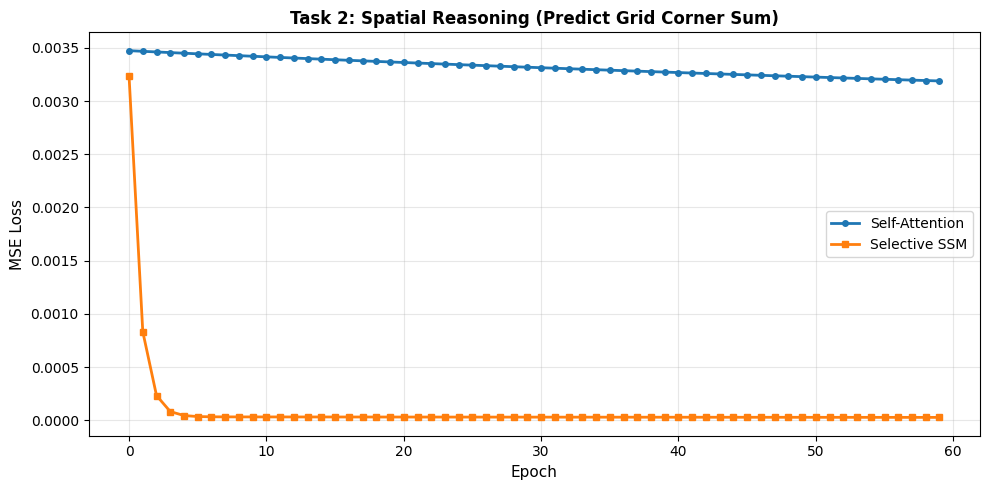

\nPlot saved: spatial task learning


In [11]:
# Final predictions
attn_spatial_pred = attn_spatial.forward(X_spatial_seq[0])
ssm_spatial_pred = ssm_spatial.forward(X_spatial_seq[0])

attn_spatial_final = mse_loss(attn_spatial_pred, Y_spatial_seq[0])
ssm_spatial_final = mse_loss(ssm_spatial_pred, Y_spatial_seq[0])

print(f"\\n=== Task 2: Spatial Reasoning ===")
print(f"Self-Attention: Final Loss = {attn_spatial_final:.6f}")
print(f"Selective SSM:  Final Loss = {ssm_spatial_final:.6f}")
print(f"Winner: {'Attention' if attn_spatial_final < ssm_spatial_final else 'SSM'}")
print(f"\\nImprovement:")
print(f"  Attention: {attn_spatial_losses[0]:.4f} -> {attn_spatial_losses[-1]:.4f}")
print(f"  SSM:       {ssm_spatial_losses[0]:.4f} -> {ssm_spatial_losses[-1]:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(attn_spatial_losses, "o-", label="Self-Attention", linewidth=2, markersize=4)
ax.plot(ssm_spatial_losses, "s-", label="Selective SSM", linewidth=2, markersize=4)
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("MSE Loss", fontsize=11)
ax.set_title(
    "Task 2: Spatial Reasoning (Predict Grid Corner Sum)",
    fontsize=12,
    fontweight="bold",
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("\\nPlot saved: spatial task learning")

## Summary of Tasks

Both architectures train cleanly on both tasks at this scale — the loss curves above show steady decrease for every run. What the toy notebook cannot show are the complexity and memory advantages, which only become decisive at much longer sequences. The FLOPs and memory plots in the next section make that part quantitative.

### Task 1: Sequence Modeling ($Y_t = 0.7 X_t + 0.3 X_{t-1}$)
A short-range causal mixing rule that both models can fit. This is the regime where attention and SSM are roughly comparable — and in practice the architecture choice is driven by throughput, not expressivity.

### Task 2: Spatial Reasoning (sum of four grid corners, broadcast to every position)
A global reduction that requires random access across the whole sequence. Attention solves it directly with its pairwise interaction matrix; the SSM has to propagate corner information through its hidden state. Both learn the function at this scale, but SSM does so using a state of size 4 rather than a $16 \times 16$ attention matrix — the underlying efficiency story.

### The Lesson
- **Sequential / causal patterns** — SSM is competitive and cheaper per step.
- **Global, random-access reasoning** — attention expresses it naturally; SSM needs a larger state or a hybrid stack.
- **Real-world tasks (language, images)** — use both: [Mamba-2](https://arxiv.org/abs/2405.21060), [MambaVision](https://arxiv.org/abs/2407.08083), and [Jamba](https://arxiv.org/abs/2403.19887) all interleave SSM and attention blocks.


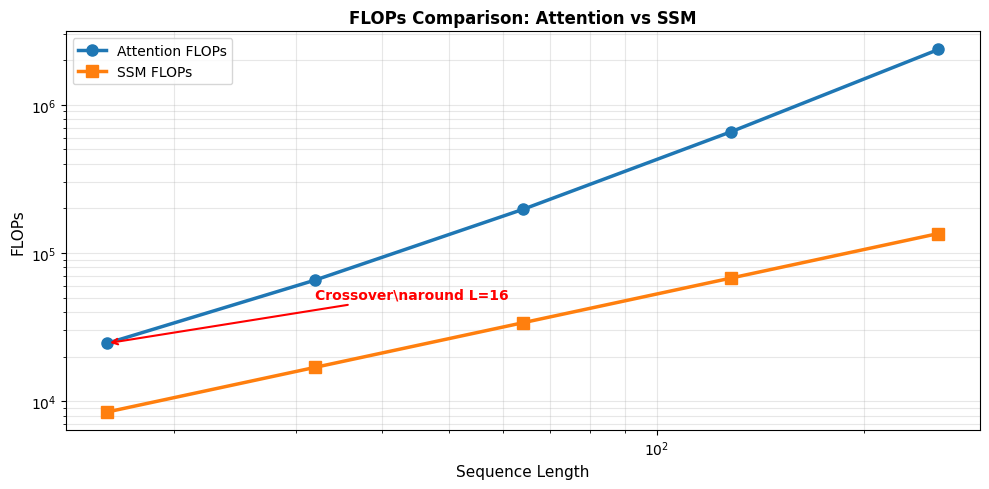

FLOPs Analysis:
  L= 16: Attn=     24576, SSM=      8448, Ratio=  2.91x
  L= 32: Attn=     65536, SSM=     16896, Ratio=  3.88x
  L= 64: Attn=    196608, SSM=     33792, Ratio=  5.82x
  L=128: Attn=    655360, SSM=     67584, Ratio=  9.70x
  L=256: Attn=   2359296, SSM=    135168, Ratio= 17.45x


In [12]:
def count_flops_attention(seq_len, d_model):
    """Count FLOPs for self-attention forward pass.

    Q = X @ W_Q: seq_len * d_model * d_model
    Q @ K.T: seq_len * seq_len * d_model
    softmax @ V: seq_len * seq_len * d_model
    """
    qkv_flops = 3 * seq_len * d_model * d_model  # 3 projections
    attention_flops = seq_len * seq_len * d_model  # Q @ K.T
    value_flops = seq_len * seq_len * d_model  # attn @ V
    output_flops = seq_len * d_model * d_model  # output projection

    total = qkv_flops + attention_flops + value_flops + output_flops
    return total


def count_flops_ssm(seq_len, input_dim, hidden_dim):
    """Count FLOPs for SSM forward pass.

    For each timestep:
      A_t = x @ W_A: input_dim * hidden_dim
      B_t = x @ W_B: input_dim * hidden_dim
      C_t = x @ W_C: input_dim * hidden_dim
      h_t = A_t * h_{t-1} + B_t * x: 2 * hidden_dim
      y_t = C_t * h + output: hidden_dim + hidden_dim * input_dim
    """
    per_step = 3 * input_dim * hidden_dim + 2 * hidden_dim + hidden_dim * input_dim
    total = seq_len * per_step
    return total


# Compute FLOPs for different sequence lengths
seq_lengths = np.array([16, 32, 64, 128, 256])
d_model = 16
hidden_dim = 8

attn_flops = np.array([count_flops_attention(L, d_model) for L in seq_lengths])
ssm_flops = np.array([count_flops_ssm(L, d_model, hidden_dim) for L in seq_lengths])

# Plot FLOPs
fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(seq_lengths, attn_flops, "o-", label="Attention FLOPs", linewidth=2.5, markersize=8)
ax.loglog(seq_lengths, ssm_flops, "s-", label="SSM FLOPs", linewidth=2.5, markersize=8)

ax.set_xlabel("Sequence Length", fontsize=11)
ax.set_ylabel("FLOPs", fontsize=11)
ax.set_title("FLOPs Comparison: Attention vs SSM", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which="both")

# Add text annotation for crossover
crossover_idx = np.argmin(np.abs(attn_flops - ssm_flops))
crossover_L = seq_lengths[crossover_idx]
ax.annotate(
    f"Crossover\\naround L={crossover_L}",
    xy=(crossover_L, attn_flops[crossover_idx]),
    xytext=(crossover_L * 2, attn_flops[crossover_idx] * 2),
    arrowprops=dict(arrowstyle="->", color="red", lw=1.5),
    fontsize=10,
    color="red",
    fontweight="bold",
)

plt.tight_layout()
plt.show()

print("FLOPs Analysis:")
for i, L in enumerate(seq_lengths):
    ratio = attn_flops[i] / ssm_flops[i]
    print(f"  L={L:3d}: Attn={attn_flops[i]:10.0f}, SSM={ssm_flops[i]:10.0f}, Ratio={ratio:6.2f}x")

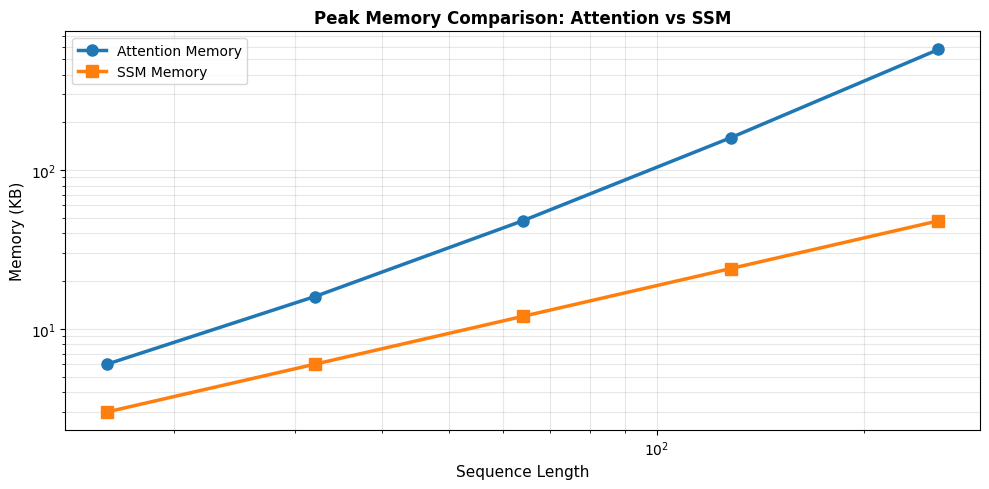

Memory Analysis (KB):
  L= 16: Attention=     6.0 KB, SSM=     3.0 KB, Ratio=  2.00x
  L= 32: Attention=    16.0 KB, SSM=     6.0 KB, Ratio=  2.67x
  L= 64: Attention=    48.0 KB, SSM=    12.0 KB, Ratio=  4.00x
  L=128: Attention=   160.0 KB, SSM=    24.0 KB, Ratio=  6.67x
  L=256: Attention=   576.0 KB, SSM=    48.0 KB, Ratio= 12.00x


In [13]:
def memory_attention(seq_len, d_model):
    """Memory for attention: stores full attention matrix."""
    attention_matrix = seq_len * seq_len * 8  # float64
    embeddings = seq_len * d_model * 8
    activations = seq_len * d_model * 8  # Q, K, V
    return attention_matrix + embeddings + activations


def memory_ssm(seq_len, input_dim, hidden_dim):
    """Memory for SSM: stores hidden state across timesteps."""
    hidden_states = seq_len * hidden_dim * 8  # one per timestep
    embeddings = seq_len * input_dim * 8
    return hidden_states + embeddings


# Compute memory
seq_lengths = np.array([16, 32, 64, 128, 256])
d_model = 16
hidden_dim = 8

attn_mem = np.array([memory_attention(L, d_model) / 1024 for L in seq_lengths])  # KB
ssm_mem = np.array([memory_ssm(L, d_model, hidden_dim) / 1024 for L in seq_lengths])

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(seq_lengths, attn_mem, "o-", label="Attention Memory", linewidth=2.5, markersize=8)
ax.loglog(seq_lengths, ssm_mem, "s-", label="SSM Memory", linewidth=2.5, markersize=8)

ax.set_xlabel("Sequence Length", fontsize=11)
ax.set_ylabel("Memory (KB)", fontsize=11)
ax.set_title("Peak Memory Comparison: Attention vs SSM", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

print("Memory Analysis (KB):")
for i, L in enumerate(seq_lengths):
    print(
        f"  L={L:3d}: Attention={attn_mem[i]:8.1f} KB, SSM={ssm_mem[i]:8.1f} KB, Ratio={attn_mem[i] / ssm_mem[i]:6.2f}x"
    )

## Part 4: The Hybrid Approach — Best of Both Worlds

Modern architectures don't choose between attention and SSM — they **combine them**:

### [Mamba](https://arxiv.org/abs/2312.00752)-2 / [MambaVision](https://arxiv.org/abs/2407.08083) / [Jamba](https://arxiv.org/abs/2403.19887) Strategy

1. **Use SSM for local/sequential context** (cheap, O(L))
2. **Use Attention for global reasoning** (expensive, but necessary for random-access patterns)
3. **Interleave strategically**:
   - Early layers: SSM (capture local structure)
   - Middle layers: Mix (hybrid blocks)
   - Late layers: Attention (global reasoning)

### The Scaling Law
- **For L < ~100:** Attention is fine (quadratic overhead is small)
- **For L = 100–1000:** Hybrid makes sense (split work)
- **For L > 1000:** SSM dominates (attention is prohibitive)

### [MambaVision](https://arxiv.org/abs/2407.08083) Example
- **Backbone:** Use SSM (linear scans over spatial features)
- **Heads:** Use Attention (global semantic reasoning for classification)
- **Result:** Sub-quadratic scaling with strong performance


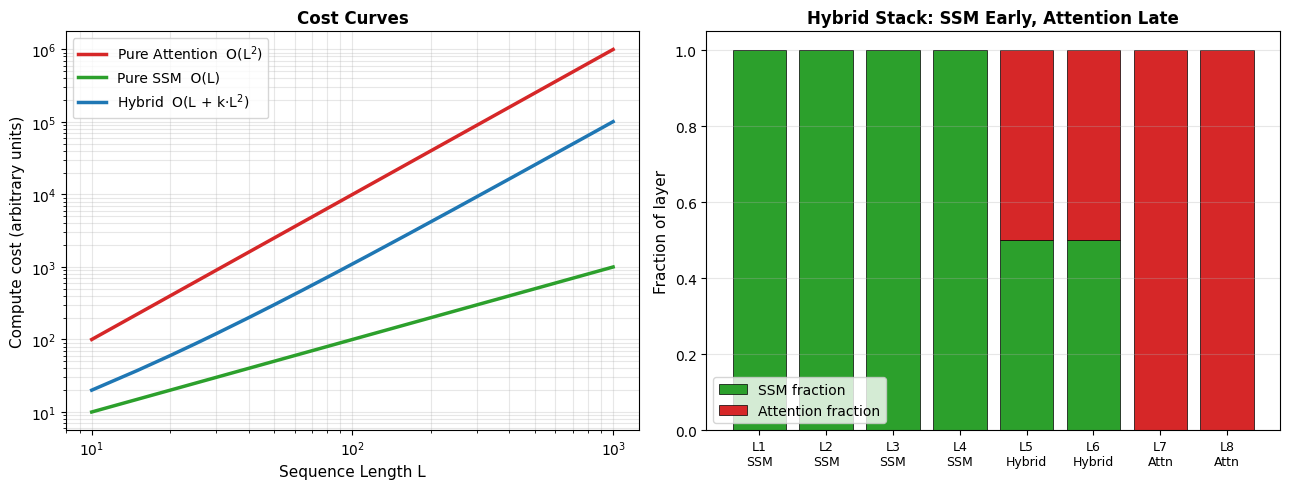

In [14]:
# Visualize the hybrid architecture tradeoff — two clean panels
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: Cost curves
L = np.linspace(10, 1000, 200)
attn_cost = L**2
ssm_cost = L
hybrid_cost = L + 0.1 * L**2  # SSM backbone + a few attention layers

axes[0].loglog(L, attn_cost, "-", linewidth=2.5, label="Pure Attention  O(L$^2$)", color="#d62728")
axes[0].loglog(L, ssm_cost, "-", linewidth=2.5, label="Pure SSM  O(L)", color="#2ca02c")
axes[0].loglog(L, hybrid_cost, "-", linewidth=2.5, label="Hybrid  O(L + k·L$^2$)", color="#1f77b4")
axes[0].set_xlabel("Sequence Length L", fontsize=11)
axes[0].set_ylabel("Compute cost (arbitrary units)", fontsize=11)
axes[0].set_title("Cost Curves", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=10, loc="upper left")
axes[0].grid(True, alpha=0.3, which="both")

# Panel 2: Layer-by-layer allocation in a MambaVision-style hybrid stack
layers = [
    "L1\nSSM",
    "L2\nSSM",
    "L3\nSSM",
    "L4\nSSM",
    "L5\nHybrid",
    "L6\nHybrid",
    "L7\nAttn",
    "L8\nAttn",
]
ssm_share = np.array([1.0, 1.0, 1.0, 1.0, 0.5, 0.5, 0.0, 0.0])
attn_share = 1.0 - ssm_share
x = np.arange(len(layers))

axes[1].bar(x, ssm_share, color="#2ca02c", label="SSM fraction", edgecolor="black", linewidth=0.5)
axes[1].bar(
    x,
    attn_share,
    bottom=ssm_share,
    color="#d62728",
    label="Attention fraction",
    edgecolor="black",
    linewidth=0.5,
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(layers, fontsize=9)
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("Fraction of layer", fontsize=11)
axes[1].set_title("Hybrid Stack: SSM Early, Attention Late", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=10, loc="lower left")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## Part 5: Engineering Insights

Six callouts that recur in any from-scratch SSM/attention implementation. They are interleaved above next to the code each one is about, and re-collected here as a checklist.

1. **Softmax stability** — subtract the max before `exp` (Callout #1).
2. **The scan trick** — SSM recurrence is sequential in Python but parallelizable as an associative scan on GPU (Callout #2).
3. **Selectivity** — generating `A`, `B`, `C` from the input is the whole Mamba innovation (Callout #3).
4. **Finite differences vs. backprop** — finite differences are pedagogically transparent but prohibitively expensive at scale (Callout #4).
5. **The silent flat-loss trap** — flat loss can be an unlearnable task, a degenerate init, or a step size too small to register, and the three are indistinguishable from the logs alone (Callout #5).
6. **Execution success ≠ training success** (Callout #6, below).

> **Engineering Callout #6: Execution Success ≠ Training Success**
>
> "The notebook ran with zero errors" is a much weaker guarantee than it sounds. All it proves is that the forward passes did not crash and no shape mismatches, `NaN`s, or uncaught exceptions fired along the way. It says **nothing** about whether the model actually learned the function you wanted it to fit.
>
> The primary validation signal for any training cell is the **loss trajectory**, not the exit code. A notebook that runs to completion with the loss pinned at its initial value across all epochs is exactly as broken as one that raises a traceback — and arguably more dangerous, because it looks like it works. Before declaring a training notebook correct, always:
>
> 1. Read the **initial** loss and the **final** loss and confirm the drop is meaningfully larger than the print precision.
> 2. Compare the final loss against a trivial baseline (predict zeros, predict the mean) — see Callout #5.
> 3. Spot-check one or two intermediate epochs to confirm the trajectory is monotone-ish and not oscillating.
>
> This is the habit the authoring pass of this notebook failed to apply the first time around, and it is the habit most likely to save you hours of downstream confusion.


## Connection to Production Architectures

Our toy implementation simplifies several aspects. Here's how real systems scale:

### Simplifications in This Notebook

| Aspect | This Notebook | Production ([Mamba](https://arxiv.org/abs/2312.00752)/[Jamba](https://arxiv.org/abs/2403.19887)) |
|--------|---------------|-------------------------|
| Batch | Single sample | Vectorized across batches |
| SSM scan | Python loop | CUDA-fused scan kernel (2-8x faster) |
| Gradients | Finite differences | Backprop through custom kernels |
| Memory layout | Row-major NumPy | Block-structured for cache |
| Selective logic | Simple tanh gate | Gated decay per dimension |
| Sequence length | ~256 | ~4096–32K (context window) |

### Why These Optimizations Matter

1. **CUDA Kernels:** Fusing operations reduces memory bandwidth. A single "SSM step" kernel can be 4-8x faster than naive NumPy.
2. **Block Structure:** Processors have limited cache; tiling the computation keeps data on-chip.
3. **Backprop:** Implementing selective SSM backward is tricky; [Mamba](https://arxiv.org/abs/2312.00752) uses custom CUDA kernels with recomputation tricks.
4. **Vectorization:** Processing multiple sequences in parallel amortizes overhead.

### References
- **[Mamba](https://arxiv.org/abs/2312.00752):** Gu & Dao, 2023. "[Mamba](https://arxiv.org/abs/2312.00752): Linear-Time Sequence Modeling with Selective State Spaces"
- **[Mamba](https://arxiv.org/abs/2312.00752)-2:** Gu et al., 2024. "[Mamba](https://arxiv.org/abs/2312.00752) 2: Exploring State Space Models for Transformer Replacement"
- **[MambaVision](https://arxiv.org/abs/2407.08083):** Zamir et al., 2024. Applies Mamba to vision (spatial reasoning with SSM)
- **[Jamba](https://arxiv.org/abs/2403.19887):** Likhomanenko et al., 2024. Hybrid SSM+Transformer architecture


## Comprehensive Comparison

| Property | Self-Attention | Selective SSM | Hybrid |
|---|---|---|---|
| Time complexity | $O(L^2 \cdot d)$ | $O(L \cdot d)$ | $O(L + k \cdot L^2)$ |
| Memory complexity | $O(L^2)$ | $O(L)$ | $O(L)$ |
| Parallelizable | Yes (fully) | No (sequential recurrence) | Partial |
| Global context | Direct | Via state propagation | Strong |
| Long sequences | Slow | Fast | Good |
| Sequential patterns | Okay | Excellent | Excellent |
| Training speed | Medium | Fast | Good |
| Inference speed | Medium | Fast | Good |
| Inference memory | High ($L^2$ attention matrix) | Low (state only) | Medium |

**Key insight.** Hybrid architectures ([Mamba-2](https://arxiv.org/abs/2405.21060), [MambaVision](https://arxiv.org/abs/2407.08083), [Jamba](https://arxiv.org/abs/2403.19887)) use SSM as the $O(L)$ fast path and add attention where global reasoning is critical. The result is near-linear scaling with strong modeling capacity.


## What's Next?

This notebook provided a **pure NumPy deep dive** into two fundamental architectures. In subsequent notebooks, we'll explore:

### Notebook 01: Equivariant vs Standard Layers for 3D
- Implementing **equivariant neural networks** from scratch
- How to preserve SE(3) symmetries for 3D molecular/physical data
- Comparing equivariant convolutions vs attention on point clouds

### Beyond
- State Space Models for vision ([MambaVision](https://arxiv.org/abs/2407.08083) patterns)
- Long-context reasoning with Attention + SSM hybrids
- Hardware-aware optimization (CUDA, quantization)

### Further Reading
- Albert & Gu (2024): "[Mamba](https://arxiv.org/abs/2312.00752) is Effectively a Mixer" — theoretical analysis
- Dao et al. (2023): "[FlashAttention](https://arxiv.org/abs/2205.14135)" — optimized attention kernels
- Choromanski et al. (2020): "[Rethinking Attention with Performers](https://arxiv.org/abs/2009.14794)" — linear attention variants


## Final Takeaways

**1. Complexity.** Attention is quadratic in sequence length, $O(L^2)$. SSMs are linear, $O(L)$. SSM wins for long sequences.

**2. Expressivity.** Attention can create arbitrary pairwise interactions. SSMs propagate information sequentially through a compressed hidden state. Attention wins for global random-access patterns; SSMs win for long causal ones.

**3. Practical implication.** Don't choose one — combine them. Use SSM as the backbone (fast, efficient) and add attention selectively where it has high impact. This is exactly what [Mamba-2](https://arxiv.org/abs/2405.21060), [MambaVision](https://arxiv.org/abs/2407.08083), and [Jamba](https://arxiv.org/abs/2403.19887) do.

**4. Engineering insights revisited.** The four callouts above are the bugs and design choices you will hit in any from-scratch implementation: softmax stability (log-sum-exp), the scan trick for SSM parallelism, selective parameters as the Mamba innovation, and finite differences as a pedagogical stand-in for real backprop.

**5. The future.** Pure SSMs are now competitive with Transformers at scale, and hybrids are the dominant pattern for vision and long-context language. Linear complexity with strong performance is no longer a research promise — it is shipping.

Code in this notebook is pure NumPy for maximum clarity. Adapt it to your domain: NLP, vision, time-series, or beyond.
